# Worksheet 9 - Dynamical Models with NNs

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.integrate import solve_ivp
from mpl_toolkits.mplot3d import Axes3D
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim
from torchdiffeq import odeint

# The training data come from scipy, and the network is a plain MLP (no torchdiffeq), so the
# MPS backend works fine here.
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps' if torch.backends.mps.is_available()
    else 'cpu'
)

np.random.seed(7)
torch.manual_seed(7)

def as_list(x):
    """Plot tensors without relying on the PyTorch-to-NumPy bridge."""
    return x.detach().cpu().tolist()

print('Using device:', device)

Using device: cpu


## 1 - Analysing the dynamics of the Lorenz system

**1.  Write a function that describes the Lorenz system:**

In [2]:
sigma, rho, beta = 10, 28, 8/3 # 'Original' parameters used by Edwards Lorenz

def lorenz(t, X, sigma, rho, beta):
    """
    Defines the Lorenz equations.

    Parameters
    ----------
    t: time
    X: input, consisting of x, y, z
    sigma: Prandtl number
    rho: Rayleigh number
    beta: physical dimension of the system

    Returns
    -------
    Derivatives of x, y and z
    """

    x, y, z = X
    dx = sigma * (y - x)
    dy = x * (rho - z) - y
    dz = x * y - beta * z

    return [dx, dy, dz]

**2. Initial conditions:**

In [3]:
epsilon = 10**(-9)

x0_1, y0_1, z0_1 = 5, 5, 5
x0_2, y0_2, z0_2 = 5, 5, 5 + epsilon

# maximum time point and number of time points

t_min, t_max, n = 0, 40, 10000

# Integrate the Lorenz equations

soln1 = solve_ivp(lorenz, (t_min, t_max), (x0_1, y0_1, z0_1), args=(sigma, rho, beta), rtol=1e-10, atol=1e-12, dense_output=True)
soln2 = solve_ivp(lorenz, (t_min, t_max), (x0_2, y0_2, z0_2), args=(sigma, rho, beta), rtol=1e-10, atol=1e-12, dense_output=True)

# Interpolate the solution onto the time grid t

t = np.linspace(t_min, t_max, n)
x1, y1, z1 = soln1.sol(t)
x2, y2, z2 = soln2.sol(t)

**3. Plot the trajectories and distance between them over time:**

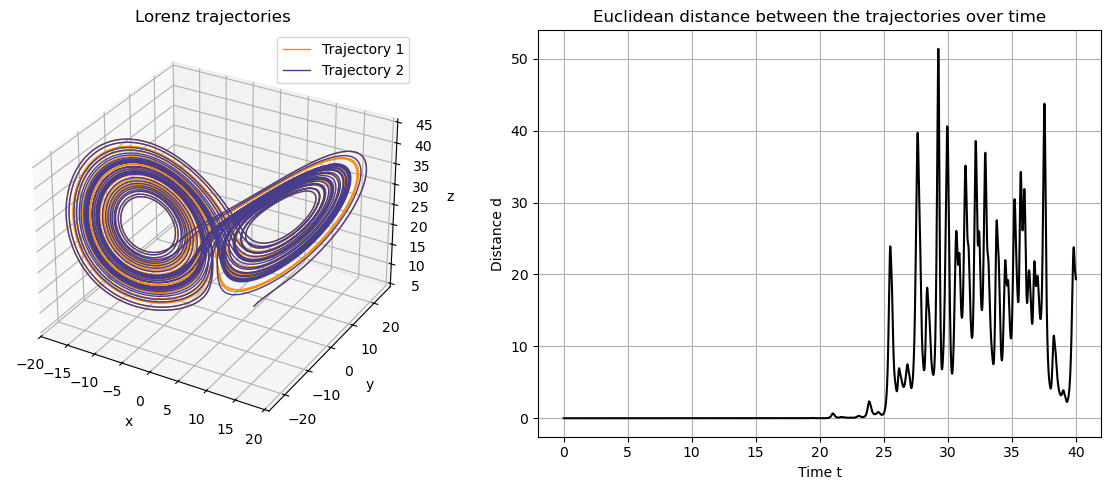

In [4]:
# euclidean distance
d = np.sqrt((x1 - x2)**2 + (y1 - y2)**2 + (z1 - z2)**2)

fig = plt.figure(figsize=(12, 5))

ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot(x1, y1, z1, label='Trajectory 1', color='darkorange', linewidth=1)
ax1.plot(x2, y2, z2, label='Trajectory 2', color='darkslateblue', linewidth=1)
ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax1.set_title('Lorenz trajectories')
ax1.legend()

ax2 = fig.add_subplot(1, 2, 2)
ax2.plot(t, d, color='black')
ax2.set_xlabel('Time t')
ax2.set_ylabel('Distance d')
ax2.set_title('Euclidean distance between the trajectories over time')
ax2.grid(True)

plt.tight_layout()
plt.show()

**4. Compute trajectories and estimate Lyapunov time for set of initial conditions:**

In [5]:
# Generate 100 pairs of two different initial conditions

N = 100

X0_1 = np.column_stack([
    np.random.uniform(-15, 15, N), # x
    np.random.uniform(-15, 15, N), # y
    np.random.uniform(0, 30, N)   # z
    ])

unit_vectors = np.array([
    [1, 0, 0],   # ex
    [0, 1, 0],   # ey
    [0, 0, 1]    # ez
])

random_vector = np.random.randint(0, 3, size=N)
e_r = unit_vectors[random_vector]

X0_2 = X0_1 + epsilon * e_r


In [6]:
# calculate the trajectories for the initial conditions defined above and the mean separation

distances = np.zeros(len(t))

for n in range (N):

    soln_X0_1 = solve_ivp(lorenz, (t_min, t_max), (X0_1[n]), args=(sigma, rho, beta), rtol=1e-10, atol=1e-12, dense_output=True)
    soln_X0_2 = solve_ivp(lorenz, (t_min, t_max), (X0_2[n]), args=(sigma, rho, beta), rtol=1e-10, atol=1e-12, dense_output=True)

    trajectory_1 = soln_X0_1.sol(t)
    trajectory_2 = soln_X0_2.sol(t)

    d = np.linalg.norm(trajectory_1 - trajectory_2, axis=0)

    distances = distances + d

mean_distance = distances / N

For Lyapunov time use:

$⟨d(t)⟩ ∼ εe^{t/τ}$ $\rarr log(d) ∼ log(ε) + \frac{t}{τ}$

Lyapunov time: τ =  1.1097242971887469


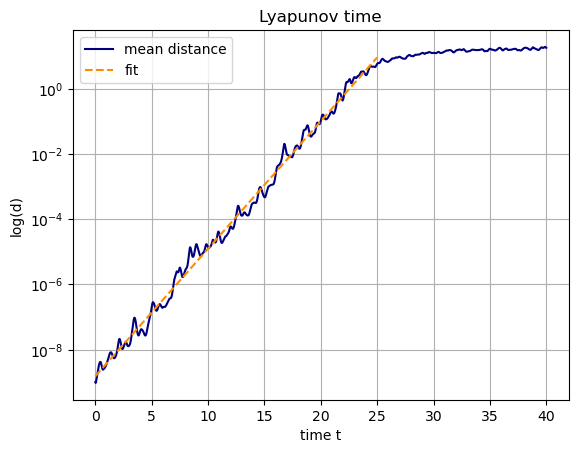

In [7]:
# Lyapunov time

# linear fit, first visually inspected when the separation saturates, which is the case at ∼ t =25
log_d = np.log(mean_distance)
mask = t<= 25
t_fit = t[mask]
log_d_fit = np.log(mean_distance[mask])

coeffs = np.polyfit(t_fit, log_d_fit, 1)
slope = coeffs[0]
intercept = coeffs[1]
tau = 1 / slope
fit = slope * t_fit + intercept

# plot
plt.semilogy(t, mean_distance, color='navy', label='mean distance')
plt.semilogy(t_fit, np.exp(fit), '--', label='fit', color='darkorange')
plt.xlabel('time t')
plt.ylabel('log(d)')
plt.title('Lyapunov time')
plt.legend()
plt.grid()

print('Lyapunov time: τ = ', tau)

## 2 - Machine Learning the dynamics of the Lorenz system

**1. Generate N = 100 random initial conditions in the same cube used for $\textbf{x}_{0, n}^{(1)}$ then compute the trajectories and split them into training and testing dataset (80% / 20%)**

In [8]:
# Initial conditions

N = 100
X0 = X0_1

# Timesteps and timespan

Nt = 400
t_2 = np.linspace(0, 4, Nt) # store trajectories at Nt = 400 uniformly spaced times between t = 0 and t = 4
trajectories = np.zeros((N, Nt, 3))

# Compute trajectories

for i in range(N):
    sol = solve_ivp(lorenz,(0, 4), X0[i], args=(sigma, rho, beta), t_eval=t_2, rtol=1e-10, atol=1e-12) # evaluate at 400 times

    trajectories[i] = sol.y.T # shape from (3, 400) to (400, 3) as trajectories[i] expects



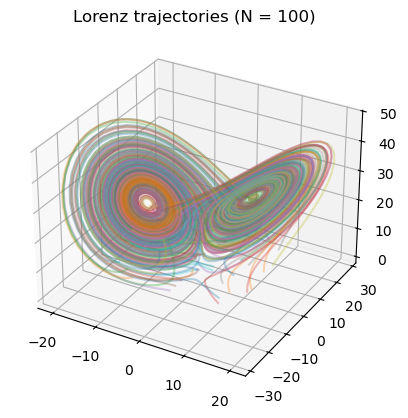

(100, 400, 3)


In [9]:
# Plot the trajectories

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for n in range(100):
    ax.plot(
        trajectories[n, :, 0],
        trajectories[n, :, 1],
        trajectories[n, :, 2],
        alpha=0.3
    )

ax1.set_xlabel('x')
ax1.set_ylabel('y')
ax1.set_zlabel('z')
ax.set_title('Lorenz trajectories (N = 100)')
plt.show()

print(trajectories.shape)

In [10]:
# Split into training and test data

ids = np.arange(N) # create IDs
train_ids, test_ids = train_test_split(ids, test_size=0.2, random_state=42)

trajectories_train = trajectories[train_ids]
trajectories_test = trajectories[test_ids]

**2. Turn trajectories into inputs and labels**

Inputs: $x(t_{k})$

Labels: $x(t_{k+1})$

In [14]:
# Flatten (Flatten all trajectories and timesteps into one list of training samples)

X_train = trajectories_train[:, :-1, :].reshape(-1, 3) # last point has no next step, so cannot be used as input, flattening collapses all but the last dimension
y_train = trajectories_train[:, 1:, :].reshape(-1, 3) # first point cannot be used because it has no input

X_test = trajectories_test[:, :-1, :].reshape(-1, 3)
y_test = trajectories_test[:, 1:, :].reshape(-1, 3)

In [15]:
# Normalization

scaler = MinMaxScaler(feature_range=(-1, 1))
scaler.fit(np.vstack([X_train, Y_train]))

X_train = scaler.transform(X_train)
y_train = scaler.transform(y_train)

X_test = scaler.transform(X_test)
y_test = scaler.transform(y_test)

**3. Build a multilayer perceptron (MLP) with the MLP starter provided**

**The one-step predictor:** A small feed-forward network maps the current state to the next state. There is **no
activation after the output layer** (we are doing regression, not classification). The
architecture mirrors the one used for the Lorenz system in the lecture, but with a 1-D
input/output here.

In [ ]:
# Build thge model

class History:
    def __init__(self):
        self.history = {'loss': [], 'val_loss': []}


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


class FeedForwardNN(nn.Module):
    """One-step predictor: maps x(t_k) -> x(t_{k+1})."""
    def __init__(self, dim=3, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, hidden),
            nn.Tanh(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, dim),   # no activation after the output
        )

    def forward(self, x):
        return self.net(x)


model = FeedForwardNN(dim=3, hidden=64).to(device)
print(model)
print(f'Trainable params: {count_parameters(model):,}')

loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

FeedForwardNN(
  (net): Sequential(
    (0): Linear(in_features=3, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)
Trainable params: 4,611


**Train:** Standard supervised regression on the one-step pairs, with an Adam optimizer and the mean
squared error. The `train_model` helper also tracks the validation loss.

In [18]:
# Train the model

def make_loader(X, y, batch_size=256, shuffle=True):
    X_tensor = torch.as_tensor(X, dtype=torch.float32)
    y_tensor = torch.as_tensor(y, dtype=torch.float32)
    return DataLoader(TensorDataset(X_tensor, y_tensor), batch_size=batch_size, shuffle=shuffle)


def train_model(model, train_loader, optimizer, loss_fn, epochs, val_loader=None):
    hist = History()
    for epoch in range(epochs):
        model.train()
        train_loss, train_count = 0.0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad(set_to_none=True)
            loss = loss_fn(model(xb), yb)
            loss.backward()
            optimizer.step()
            train_loss += loss.item() * xb.shape[0]
            train_count += xb.shape[0]
        train_loss /= train_count
        hist.history["loss"].append(train_loss)
        message = f"Epoch {epoch + 1}/{epochs} - loss: {train_loss:.6g}"

        if val_loader is not None:
            model.eval()
            val_loss, val_count = 0.0, 0
            with torch.no_grad():
                for xb, yb in val_loader:
                    xb, yb = xb.to(device), yb.to(device)
                    val_loss += loss_fn(model(xb), yb).item() * xb.shape[0]
                    val_count += xb.shape[0]
            val_loss /= val_count
            hist.history["val_loss"].append(val_loss)
            message += f" - val_loss: {val_loss:.6g}"

        if epoch == 0 or (epoch + 1) % 10 == 0:
            print(message)
    return hist


train_loader = make_loader(X_train, y_train, batch_size=256, shuffle=True)
val_loader = make_loader(X_test, y_test, batch_size=256, shuffle=False)
hist = train_model(model, train_loader, optimizer, loss_fn, epochs=200, val_loader=val_loader)

Epoch 1/200 - loss: 0.0137555 - val_loss: 0.000339065
Epoch 10/200 - loss: 2.2091e-05 - val_loss: 2.161e-05
Epoch 20/200 - loss: 1.06619e-05 - val_loss: 9.2614e-06
Epoch 30/200 - loss: 7.87532e-06 - val_loss: 1.09865e-05
Epoch 40/200 - loss: 6.79413e-06 - val_loss: 4.15603e-06
Epoch 50/200 - loss: 4.84401e-06 - val_loss: 2.774e-05
Epoch 60/200 - loss: 4.72206e-06 - val_loss: 2.00845e-06
Epoch 70/200 - loss: 3.62801e-06 - val_loss: 5.88791e-06
Epoch 80/200 - loss: 3.81835e-06 - val_loss: 8.45822e-06
Epoch 90/200 - loss: 3.28468e-06 - val_loss: 4.48575e-06
Epoch 100/200 - loss: 3.11314e-06 - val_loss: 1.71722e-06
Epoch 110/200 - loss: 3.54562e-06 - val_loss: 1.28961e-06
Epoch 120/200 - loss: 3.85009e-06 - val_loss: 5.46202e-06
Epoch 130/200 - loss: 2.38266e-06 - val_loss: 1.37678e-06
Epoch 140/200 - loss: 2.3806e-06 - val_loss: 3.21751e-06
Epoch 150/200 - loss: 2.87429e-06 - val_loss: 2.11768e-06
Epoch 160/200 - loss: 3.25772e-06 - val_loss: 1.04491e-06
Epoch 170/200 - loss: 3.46951e-06 

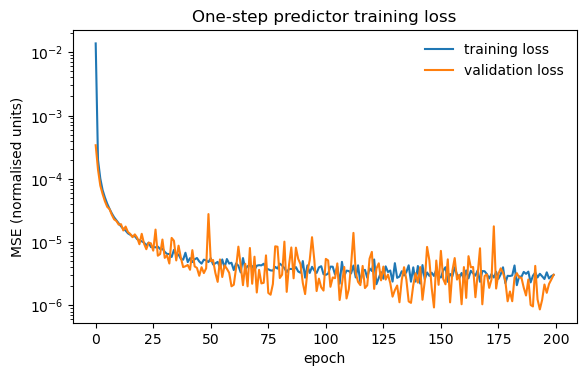

In [19]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.semilogy(hist.history['loss'], label='training loss')
ax.semilogy(hist.history['val_loss'], label='validation loss')
ax.legend(frameon=False)
ax.set_xlabel('epoch')
ax.set_ylabel('MSE (normalised units)')
ax.set_title('One-step predictor training loss')
plt.show()

**4. Compare true vs. predicted trajectories for a view initial conditions:** 

**Autoregressive rollout:** The trained network only predicts a single step. To reconstruct a whole trajectory we start
from $x_0$ and repeatedly feed the prediction back in. We compare the rollout against the true
solution for a few initial conditions taken from the held-out **test** trajectories.

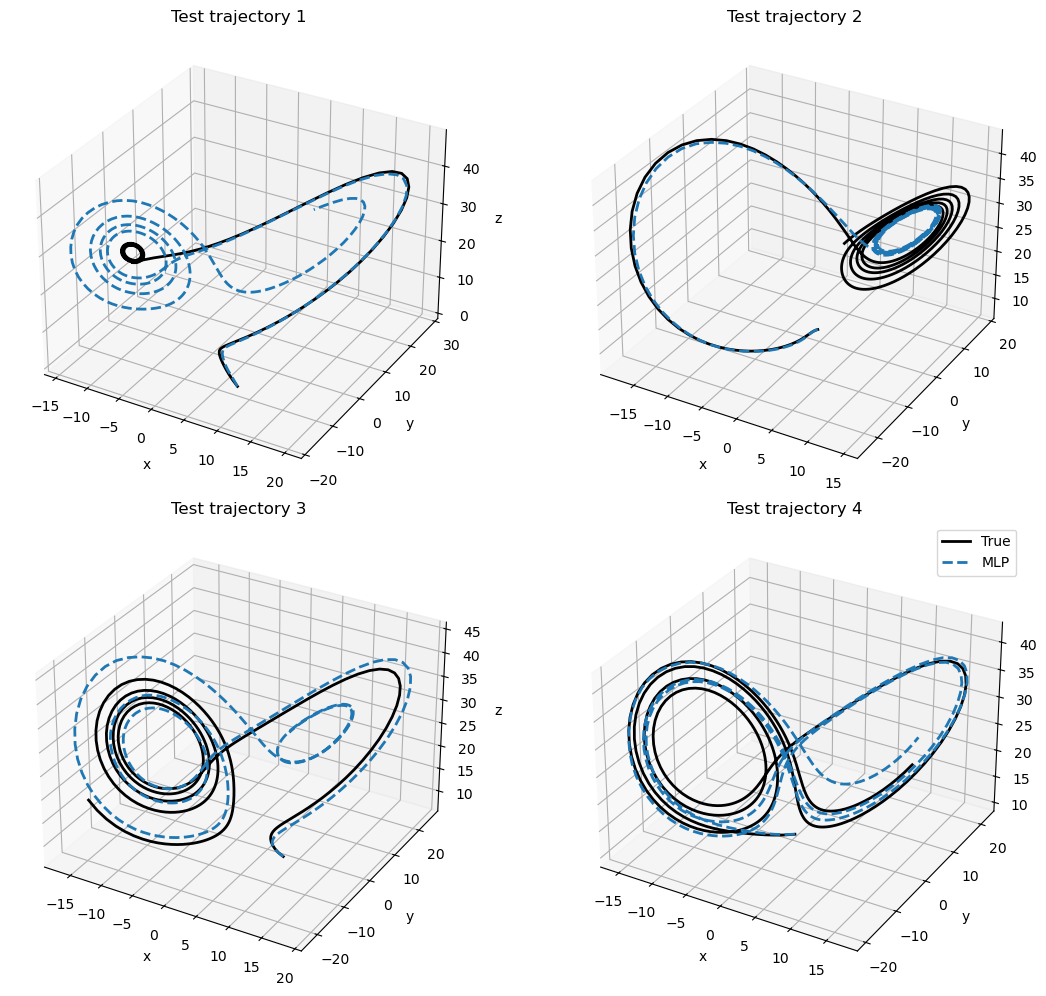

In [22]:
def rollout(model, x0, n_steps):
    """Iterate the one-step predictor n_steps times, starting from x0 (in physical units)."""
    model.eval()
    xs = np.zeros((n_steps + 1, 3)) # change for Lorenz system
    xs[0] = x0
    with torch.no_grad():
        for k in range(n_steps):
            xn = scaler.transform(xs[k].reshape(1,3)) # change for Lorenz system
            xn_next = model(torch.as_tensor(xn, dtype=torch.float32, device=device)).cpu().numpy()
            xs[k + 1] = scaler.inverse_transform(xn_next)[0] # change also
    return xs


# evaluate on the held-out test trajectories: start the rollout from each test trajectory's
# initial point and compare against the stored true trajectory (no re-integration needed)
n_show = min(4, trajectories_test.shape[0])
fig = plt.figure(figsize=(12, 10))
for j in range(n_show):
    ax = fig.add_subplot(2, 2, j + 1, projection='3d')

    true_i = trajectories_test[j]
    pred_i = rollout(model, true_i[0], Nt - 1)

    ax.plot(true_i[:, 0], true_i[:, 1], true_i[:, 2], color='k', lw=2, label='True')
    ax.plot(pred_i[:, 0], pred_i[:, 1], pred_i[:, 2], '--', lw=2, label='MLP')
    ax.set_title(f'Test trajectory {j+1}')
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')

ax.legend()
plt.tight_layout()
plt.show()